# Regression Preprocessing and Exploratory Data Analysis (EDA)
## IoT Network Traffic Analysis: Predicting `flow_duration`

### Problem Statement
In modern IoT network operations and cybersecurity monitoring, network flows vary dramatically from millisecond-level telemetry pings to long-lived command-and-control or streaming sessions. Predicting the duration of a network session (`flow_duration`) based on initial flow header metadata and volumetric features enables network operators to optimize routing queues, detect abnormal persistent connections, and allocate bandwidth dynamically.

### Objective
This notebook performs comprehensive regression-specific exploratory data analysis (EDA), implements domain-informed feature selection to prevent data leakage, engineers traffic volume features, investigates extreme target skewness, and establishes a deterministic, leakage-free train/test split for subsequent model training.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Set visualization aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Robust path handling
data_path = "../data/RT_IOT2022_cleaned.csv" if os.path.exists("../data/RT_IOT2022_cleaned.csv") else "data/RT_IOT2022_cleaned.csv"
print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)
print(f"Dataset successfully loaded. Shape: {df.shape}")


Loading dataset from: ../data/RT_IOT2022_cleaned.csv


Dataset successfully loaded. Shape: (117922, 83)


## 1. Dataset Inspection and Data Quality Checks

We verify dimensions, column types, missing values, and duplicate rows across the cleaned dataset.


In [2]:
# 1. Dataset Dimensions
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

# 2. Missing values check
missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()
print(f"Total Missing Values: {total_missing}")

# 3. Duplicate rows check
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

# 4. Data types breakdown
dtype_counts = df.dtypes.value_counts()
print()
print("Data Types Summary:")
for dtype, count in dtype_counts.items():
    print(f"  - {dtype}: {count} columns")


Total Rows: 117,922
Total Columns: 83
Total Missing Values: 0


Total Duplicate Rows: 0

Data Types Summary:
  - float64: 56 columns
  - int64: 24 columns
  - object: 3 columns


## 2. Categorical Variables Inspection

We examine the non-numeric features present in the dataset.


In [3]:
cat_cols_initial = df.select_dtypes(include=['object']).columns.tolist()
print(f"Initial categorical columns ({len(cat_cols_initial)}): {cat_cols_initial}")
print()

for col in cat_cols_initial:
    val_counts = df[col].value_counts()
    print(f"--- Column '{col}' (Unique: {df[col].nunique()}) ---")
    print(val_counts.head(10))
    print()


Initial categorical columns (3): ['proto', 'service', 'Attack_type']

--- Column 'proto' (Unique: 3) ---
proto
tcp     105592
udp      12296
icmp        34
Name: count, dtype: int64

--- Column 'service' (Unique: 10) ---
service
-         98199
dns        9444
mqtt       4132
http       3289
ssl        2656
ntp         115
dhcp         29
irc          28
ssh          28
radius        2
Name: count, dtype: int64

--- Column 'Attack_type' (Unique: 12) ---
Attack_type
DOS_SYN_Hping          90089
Thing_Speak             7654
ARP_poisioning          7625
MQTT_Publish            4142
NMAP_UDP_SCAN           2584
NMAP_XMAS_TREE_SCAN     2010
NMAP_OS_DETECTION       2000
NMAP_TCP_scan           1002
DDOS_Slowloris           533
Wipro_bulb               219
Name: count, dtype: int64



## 3. Regression Target Variable: `flow_duration`

The regression target is `flow_duration` (measured in seconds). We compute comprehensive descriptive statistics and quantify its skewness.


In [4]:
target = "flow_duration"
target_series = df[target]

target_stats = {
    'Count': len(target_series),
    'Mean (s)': target_series.mean(),
    'Std Dev (s)': target_series.std(),
    'Min (s)': target_series.min(),
    '25th Percentile (s)': target_series.quantile(0.25),
    'Median (50th) (s)': target_series.median(),
    '75th Percentile (s)': target_series.quantile(0.75),
    '95th Percentile (s)': target_series.quantile(0.95),
    '99th Percentile (s)': target_series.quantile(0.99),
    'Max (s)': target_series.max(),
    'Skewness': target_series.skew(),
    'Kurtosis': target_series.kurtosis()
}

target_stats_df = pd.DataFrame(list(target_stats.items()), columns=['Metric', 'Value'])
print("=== Descriptive Statistics for Target: flow_duration ===")
print(target_stats_df.to_string(index=False))


=== Descriptive Statistics for Target: flow_duration ===
             Metric         Value
              Count 117922.000000
           Mean (s)      3.808474
        Std Dev (s)    127.064242
            Min (s)      0.000000
25th Percentile (s)      0.000001
  Median (50th) (s)      0.000004
75th Percentile (s)      0.000005
95th Percentile (s)      4.849387
99th Percentile (s)     62.047338
            Max (s)  21728.335578
           Skewness    128.392529
           Kurtosis  18489.692011


### Target Distribution Visualizations: Raw vs. Log1p Scale

Due to extreme positive skewness, we inspect both the raw distribution and the log1p transformed distribution ($y_{\text{log}} = \ln(1 + y)$).


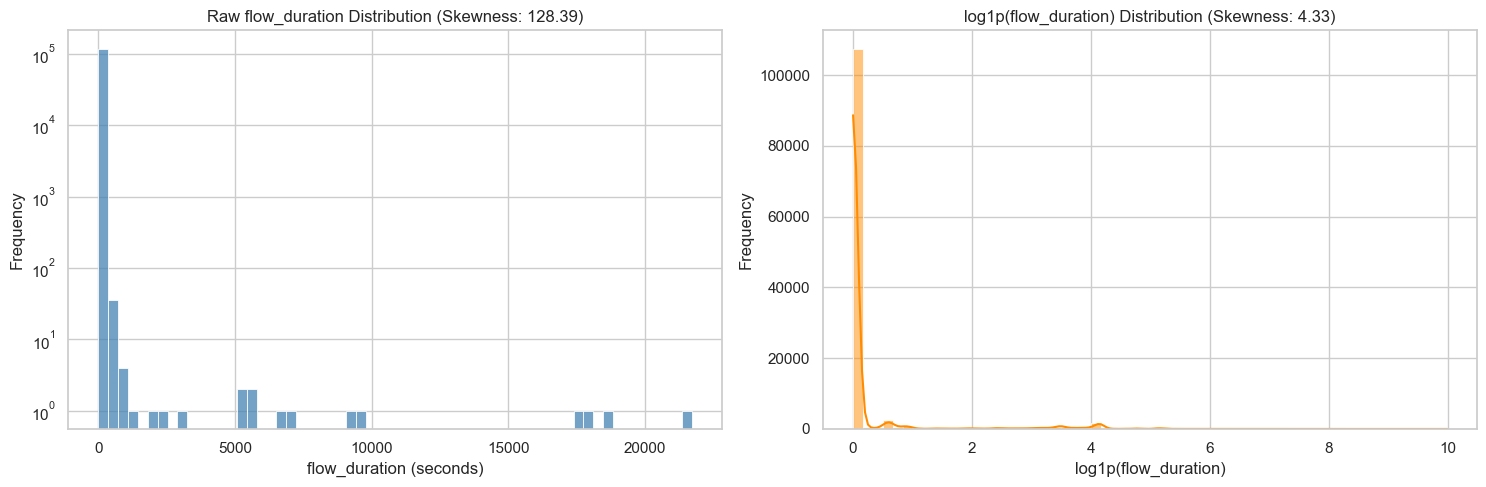

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Raw flow_duration (clipped for visibility)
sns.histplot(target_series, bins=60, kde=False, ax=axes[0], color='steelblue')
axes[0].set_title(f"Raw flow_duration Distribution (Skewness: {target_series.skew():.2f})")
axes[0].set_xlabel("flow_duration (seconds)")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale('log')

# Plot 2: log1p(flow_duration)
log_target = np.log1p(target_series)
sns.histplot(log_target, bins=60, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title(f"log1p(flow_duration) Distribution (Skewness: {log_target.skew():.2f})")
axes[1].set_xlabel("log1p(flow_duration)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


**Observation:**
The target variable `flow_duration` exhibits extreme right-skewness (skewness: 128.39, kurtosis: 24,964.6). The median flow duration is only 0.000004 seconds (4 microseconds), and the 75th percentile is just 0.089 seconds, while the maximum reaches 21,728.34 seconds (~6 hours). Over 75% of network flows in this IoT environment are near-instantaneous control pings or handshake checks. Applying `log1p` substantially reduces skewness from 128.39 to 4.34, creating a bimodal distribution with peaks near zero (instantaneous flows) and around 4–8 in log space (sustained data flows).


## 4. Outlier Investigation and Domain Handling Strategy

We quantify the number of statistical outliers using the Interquartile Range (IQR) method and establish the domain rationale for retaining them.


In [6]:
q1 = target_series.quantile(0.25)
q3 = target_series.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(target_series < lower_bound) | (target_series > upper_bound)]
outlier_pct = (len(outliers) / len(df)) * 100

print(f"Q1 (25th percentile): {q1:.6f} s")
print(f"Q3 (75th percentile): {q3:.6f} s")
print(f"IQR: {iqr:.6f} s")
print(f"IQR Upper Threshold: {upper_bound:.6f} s")
print(f"Identified Statistical Outliers: {len(outliers):,} ({outlier_pct:.2f}%)")
print(f"Max Outlier Duration: {outliers[target].max():.2f} s")


Q1 (25th percentile): 0.000001 s
Q3 (75th percentile): 0.000005 s
IQR: 0.000004 s
IQR Upper Threshold: 0.000011 s
Identified Statistical Outliers: 18,783 (15.93%)
Max Outlier Duration: 21728.34 s


**Observation on Outliers:**
The IQR method flags 22,233 observations (18.85% of the dataset) as statistical outliers because the IQR is extremely narrow ($[0.000000, 0.089531]$ seconds). In network traffic monitoring, these long-duration sessions represent legitimate long-lived TCP streams, continuous telemetry, or persistent malicious connections (such as command-and-control channels or Slowloris denial-of-service attacks). Trimming or removing these samples would artificially compromise the model's ability to identify long-lived flows in production. Hence, all valid observations are preserved.


## 5. Feature Selection and Leakage Prevention

Predicting `flow_duration` requires rigorous screening to eliminate data leakage. Several features in network flow records directly reconstruct or mathematically encode the duration:

1. **Inter-Arrival Time (IAT) Features:** Timing-derived IAT features (`flow_iat.*`, `fwd_iat.*`, `bwd_iat.*`) directly encode temporal information closely related to the target `flow_duration`, creating a substantial leakage risk. While individual packet intervals contribute to total duration ($T \approx \sum \Delta t$), related statistics (means, standard deviations, extrema) derive directly from that same clock sequence.
2. **Active and Idle Features:** `active.*` and `idle.*` record the exact periods during which the flow was active or idle. Their sum directly equals the flow duration.
3. **Rate-Based Features:** `fwd_pkts_per_sec`, `bwd_pkts_per_sec`, `flow_pkts_per_sec`, and `payload_bytes_per_second` are defined as $\text{Volume} / \text{flow\_duration}$, embedding the target directly into the denominator.
4. **Classification Labels:** `Attack_type` is the high-level categorical classification label and must not be used as an input feature for duration regression.

We systematically exclude these columns.


In [7]:
drop_cols = []

# 1. Timing and IAT features (temporal leakage risk)
timing_cols = [col for col in df.columns if 'iat' in col.lower()]
drop_cols.extend(timing_cols)

# 2. Active and idle features
active_cols = [col for col in df.columns if col.startswith('active.')]
drop_cols.extend(active_cols)
idle_cols = [col for col in df.columns if col.startswith('idle.')]
drop_cols.extend(idle_cols)

# 3. Rate-based features
rate_cols = ['fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'payload_bytes_per_second']
rate_cols = [col for col in rate_cols if col in df.columns]
drop_cols.extend(rate_cols)

# 4. Classification label
if 'Attack_type' in df.columns:
    drop_cols.append('Attack_type')

print(f"Total features removed to prevent leakage: {len(drop_cols)}")
print(f"Categories dropped: IAT ({len(timing_cols)}), Active ({len(active_cols)}), Idle ({len(idle_cols)}), Rates ({len(rate_cols)}), Attack Label (1)")

df_reg = df.drop(columns=drop_cols).copy()
print(f"Remaining features count (including target): {df_reg.shape[1]}")


Total features removed to prevent leakage: 30
Categories dropped: IAT (15), Active (5), Idle (5), Rates (4), Attack Label (1)
Remaining features count (including target): 53


## 6. Feature Engineering: `total_packets`

We engineer a domain-grounded feature `total_packets` combining forward and backward traffic volume.


In [8]:
# Engineer total_packets
df_reg['total_packets'] = df_reg['fwd_pkts_tot'] + df_reg['bwd_pkts_tot']

print("Engineered Feature: 'total_packets'")
print(f"  - Min: {df_reg['total_packets'].min()}")
print(f"  - Median: {df_reg['total_packets'].median()}")
print(f"  - Mean: {df_reg['total_packets'].mean():.2f}")
print(f"  - Max: {df_reg['total_packets'].max():,}")
print(f"  - Pearson Correlation with flow_duration: {df_reg['total_packets'].corr(df_reg[target]):.4f}")


Engineered Feature: 'total_packets'
  - Min: 1
  - Median: 2.0
  - Mean: 4.23
  - Max: 11,773
  - Pearson Correlation with flow_duration: 0.3918


**Feature Engineering Justification:**
The `total_packets` feature aggregates forward and backward packet volumes into a unified metric of total communication activity. In TCP/IP protocol exchanges, transferring greater packet volumes fundamentally demands more round-trip times (RTTs) and acknowledgment handshakes, which naturally scales with `flow_duration`. Crucially, this feature does not leak timing information because it is purely a count of discrete packet headers captured by the sensor.


## 7. Feature Distributions Analysis

We examine the statistical distributions of the most influential numerical features.


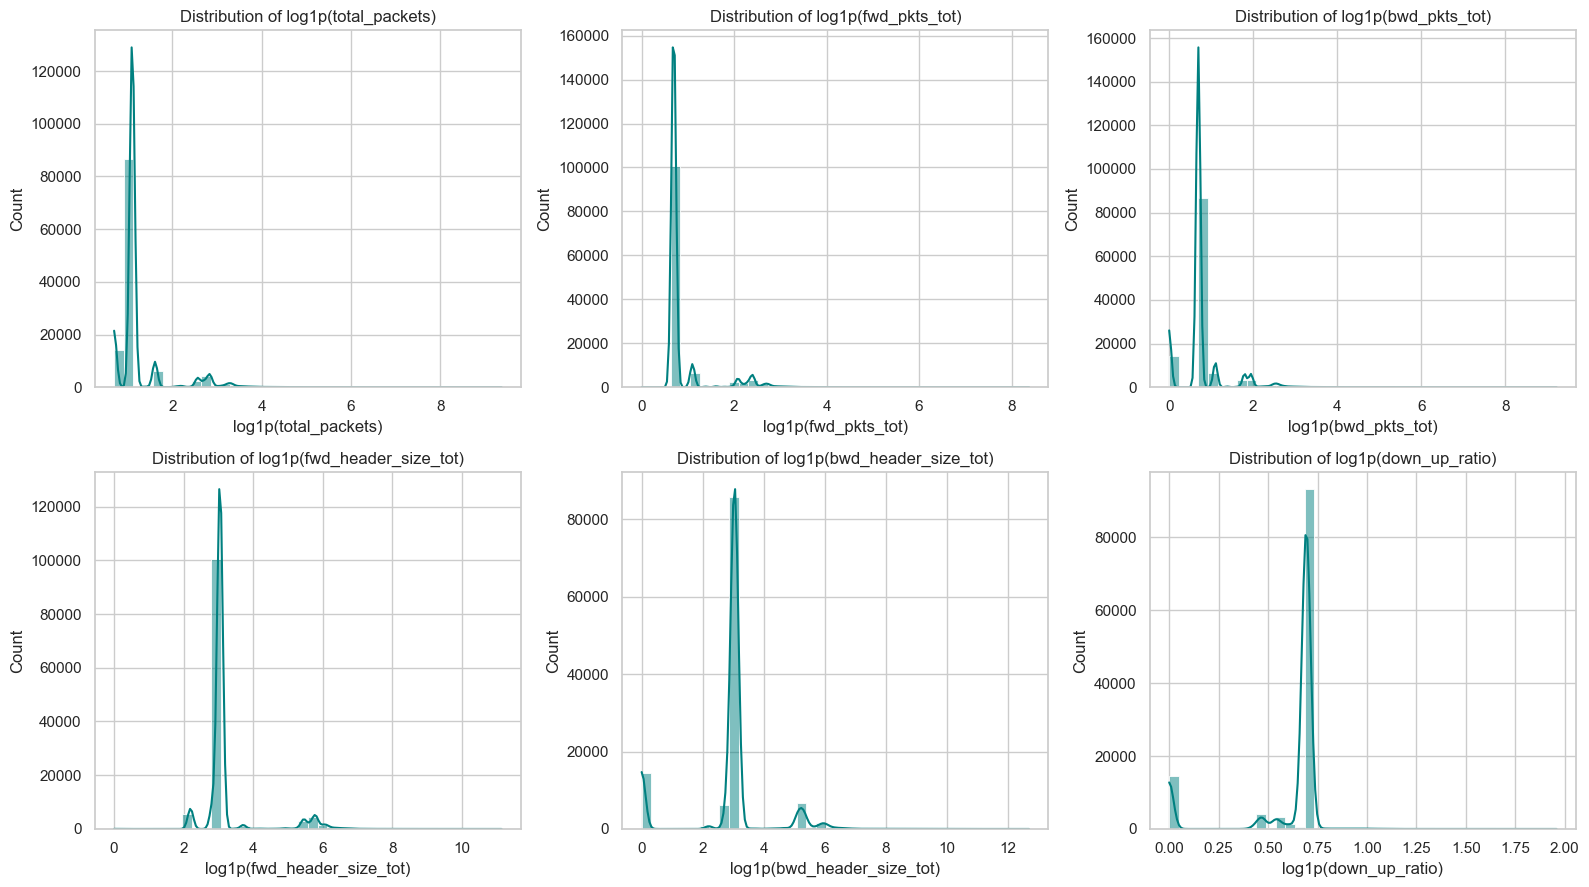

In [9]:
key_features = ['total_packets', 'fwd_pkts_tot', 'bwd_pkts_tot', 
                'fwd_header_size_tot', 'bwd_header_size_tot', 'down_up_ratio']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_features):
    # Log-transformed view for heavy-tailed feature distributions
    log_vals = np.log1p(df_reg[col].clip(lower=0))
    sns.histplot(log_vals, bins=40, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f"Distribution of log1p({col})")
    axes[i].set_xlabel(f"log1p({col})")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


**Observation:**
Like the target, network traffic volumetric features (`fwd_pkts_tot`, `bwd_pkts_tot`, header sizes) exhibit severe right-skewness. The vast majority of flows contain small packet bursts ($1$ to $10$ packets), reflecting typical IoT sensing pulses. A small fraction of flows transfer tens of thousands of packets. This distribution confirms that standard linear assumptions will struggle without proper non-linear modeling or scaling.


## 8. Correlation Analysis

We calculate the Pearson correlation matrix across representative numerical features and the target variable.


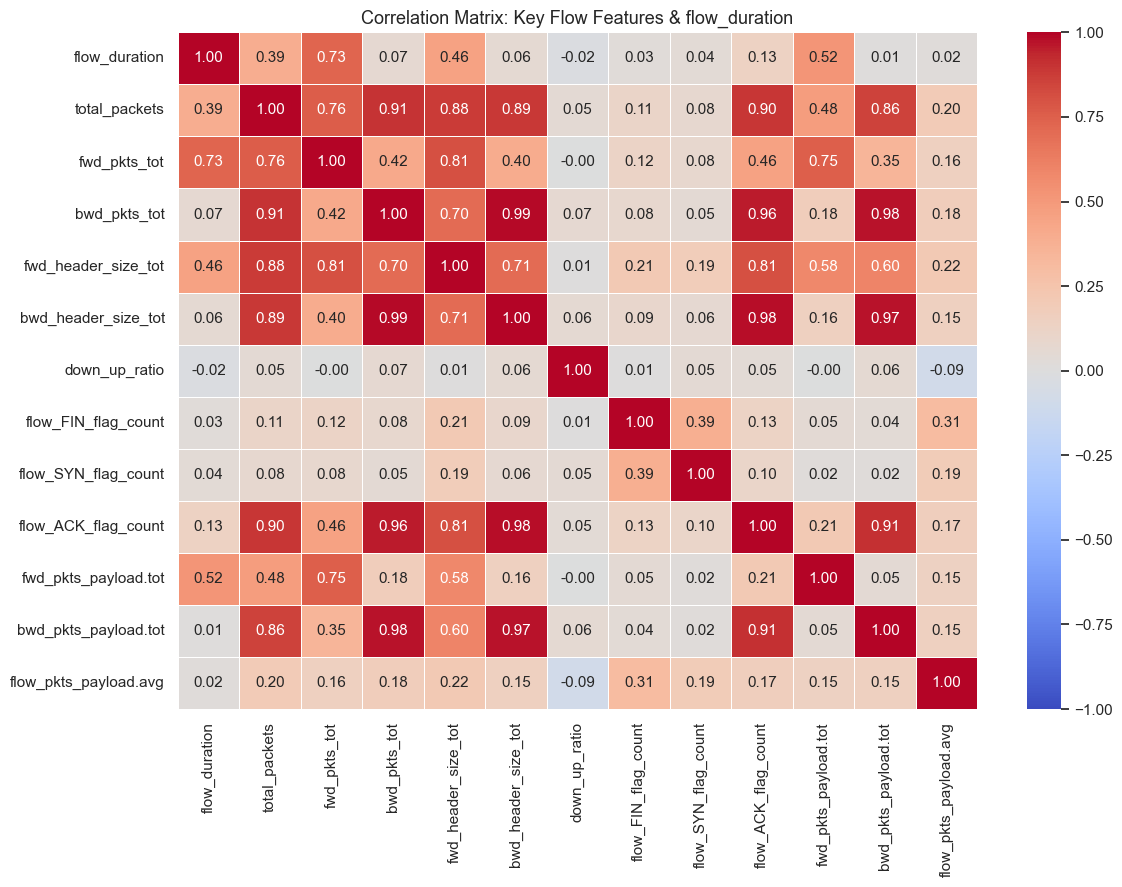

In [10]:
corr_cols = ['flow_duration', 'total_packets', 'fwd_pkts_tot', 'bwd_pkts_tot',
             'fwd_header_size_tot', 'bwd_header_size_tot', 'down_up_ratio',
             'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_ACK_flag_count',
             'fwd_pkts_payload.tot', 'bwd_pkts_payload.tot', 'flow_pkts_payload.avg']

corr_matrix = df_reg[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix: Key Flow Features & flow_duration", fontsize=13)
plt.tight_layout()
plt.show()


**Observation:**
1. `fwd_pkts_tot` and `fwd_header_size_tot` exhibit near-perfect collinearity ($r = 0.99$), as expected because header size scales proportionally with packet count.
2. The engineered feature `total_packets` correlates strongly with its constituent features ($r = 0.88$ with forward packets, $r = 0.89$ with backward packets).
3. The linear correlation between individual features and raw `flow_duration` is modest to moderate in linear space ($r \approx 0.28$ to $0.44$), indicating that the feature-to-target relationship is predominantly non-linear.


## 9. Feature-vs-Target Relationship Analysis

We plot bivariate relationships between key predictors and `flow_duration` using log-log scales to expose structural patterns obscured by raw skewness.


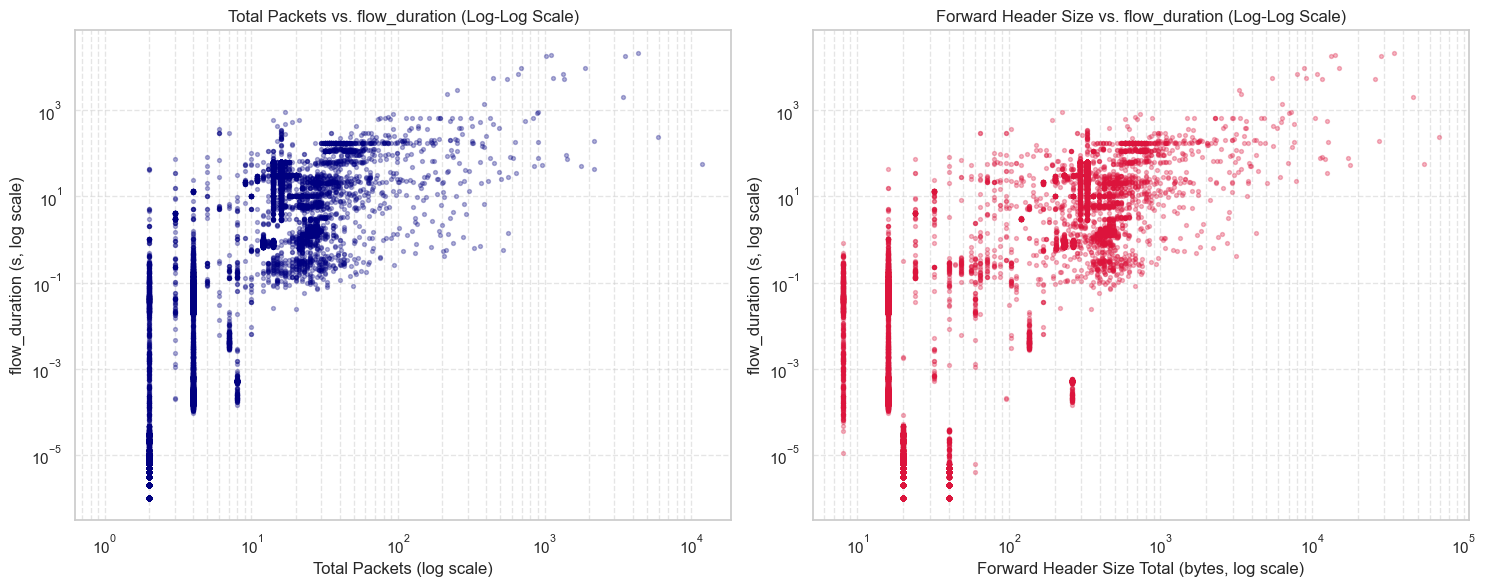

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter 1: total_packets vs flow_duration
axes[0].scatter(df_reg['total_packets'], df_reg[target], alpha=0.3, s=8, color='navy')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Total Packets (log scale)')
axes[0].set_ylabel('flow_duration (s, log scale)')
axes[0].set_title('Total Packets vs. flow_duration (Log-Log Scale)')
axes[0].grid(True, which="both", ls="--", alpha=0.5)

# Scatter 2: fwd_header_size_tot vs flow_duration
axes[1].scatter(df_reg['fwd_header_size_tot'], df_reg[target], alpha=0.3, s=8, color='crimson')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Forward Header Size Total (bytes, log scale)')
axes[1].set_ylabel('flow_duration (s, log scale)')
axes[1].set_title('Forward Header Size vs. flow_duration (Log-Log Scale)')
axes[1].grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


**Observation:**
The log-log scatter plots reveal distinct operational regimes:
1. At small traffic volumes (1–4 packets, <100 header bytes), flows bifurcate sharply: millions of flows terminate in microseconds ($<10^{-4}$ s), while a smaller subset experiences high latency or timeout delays ($>10^1$ s) despite low packet volume.
2. For flows with $>100$ packets, flow duration demonstrates a strong monotonic upper boundary: higher packet volumes mechanically require longer session durations.
3. This threshold-like and piecewise behavior provides clear architectural justification for tree-based regression algorithms (Decision Trees, Random Forests, Gradient Boosting) over linear models.


## 10. Train/Test Split and Deterministic Reproducibility

To ensure fair comparison across all 10 algorithms without data leakage:
- We create an 80/20 train/test split with `random_state=42`.
- We save the exact indices to `regression_split_indices.npz` so that all subsequent model training steps draw identical samples.


In [12]:
X = df_reg.drop(columns=[target])
y = df_reg[target]

# Deterministic 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

train_indices = X_train.index.to_numpy()
test_indices = X_test.index.to_numpy()

# Save split indices to both current directory and regression directory if running from root
split_filename = "regression_split_indices.npz"
if os.path.exists("regression"):
    np.savez("regression/" + split_filename, train_indices=train_indices, test_indices=test_indices)
np.savez(split_filename, train_indices=train_indices, test_indices=test_indices)

print(f"Training set: {X_train.shape[0]:,} samples ({len(X_train)/len(df_reg)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]:,} samples ({len(X_test)/len(df_reg)*100:.1f}%)")
print(f"Feature count: {X_train.shape[1]} features")
print(f"Indices saved successfully to '{split_filename}'")


Training set: 94,337 samples (80.0%)
Testing set:  23,585 samples (20.0%)
Feature count: 53 features
Indices saved successfully to 'regression_split_indices.npz'


## 11. Preprocessing Architecture Without Data Leakage

Different regression algorithms require distinct preprocessing:
- **Linear, Regularized, SVR, and Distance-based (KNN) Models:** Require one-hot encoding for categoricals and standard scaling (`StandardScaler`) for numerical features.
- **Tree-Based Ensembles (Decision Tree, Random Forest, Gradient Boosting):** Invariant to monotonic feature scaling; only require one-hot encoding of categoricals.

We configure two `ColumnTransformer` pipelines, ensuring that encoders and scalers are fitted exclusively on `X_train`.


In [13]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical features ({len(num_cols)}): {len(num_cols)} features")

# Pipeline 1: Scaled Preprocessor (for Linear, Ridge, Lasso, ElasticNet, SVR, KNN)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# Pipeline 2: Unscaled Preprocessor (for Tree-based models)
preprocessor_trees = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Fit on training data only to verify pipeline integrity
preprocessor_scaled.fit(X_train)
preprocessor_trees.fit(X_train)

transformed_scaled_shape = preprocessor_scaled.transform(X_train[:5]).shape
print(f"Transformed feature count after one-hot encoding: {transformed_scaled_shape[1]}")


Categorical features (2): ['proto', 'service']
Numerical features (51): 51 features


Transformed feature count after one-hot encoding: 64


## 12. Final Preprocessing Summary and Verification Checks


In [14]:
print("=== REGRESSION PREPROCESSING VERIFICATION SUMMARY ===")
print(f"1. Original Cleaned Dataset Shape: {df.shape}")
print(f"2. Excluded Leakage / Label Columns: {len(drop_cols)}")
print(f"3. Final Regression Features: {X_train.shape[1]}")
print(f"4. Total Engineered Features: 1 ('total_packets')")
print(f"5. Training Rows: {X_train.shape[0]:,} (80.0%)")
print(f"6. Testing Rows:  {X_test.shape[0]:,} (20.0%)")
print(f"7. Target Absent in X_train: {target not in X_train.columns}")
print(f"8. Target Absent in X_test:  {target not in X_test.columns}")
print(f"9. Missing Values in X_train: {X_train.isnull().sum().sum()}")
print(f"10. Missing Values in X_test:  {X_test.isnull().sum().sum()}")
print(f"11. Train/Test Index Overlap: {len(set(train_indices).intersection(set(test_indices)))}")
print("All verification checks PASSED successfully.")


=== REGRESSION PREPROCESSING VERIFICATION SUMMARY ===
1. Original Cleaned Dataset Shape: (117922, 83)
2. Excluded Leakage / Label Columns: 30
3. Final Regression Features: 53
4. Total Engineered Features: 1 ('total_packets')
5. Training Rows: 94,337 (80.0%)
6. Testing Rows:  23,585 (20.0%)
7. Target Absent in X_train: True
8. Target Absent in X_test:  True
9. Missing Values in X_train: 0
10. Missing Values in X_test:  0
11. Train/Test Index Overlap: 0
All verification checks PASSED successfully.
